In [ ]:
# ==================== 智能学术论文助手（精简修正版） ====================
# 修正: 使用条件边（conditional edge）返回 Send 列表，实现正确的并行广播

# 1. 导入模块
from typing import TypedDict, List, Annotated, Dict, Literal
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send                               # 引入Send原语
from langchain.chat_models import init_chat_model

# ---------- 大模型配置（请修改为你的 ollama 地址） ----------
model = init_chat_model(
    model="ollama:qwen3.5:9b",
    temperature=0.5,
    base_url="http://127.0.0.1:11434"                       # 请替换为你的实际地址
)

# ---------- 精简的状态定义 ----------
class OverallState(TypedDict):
    topic: str
    collected_materials: Annotated[List[str], operator.add]    # 用于聚合并行结果
    outline: str
    draft: str
    references: str
    review_feedback: str
    retry_count: int
    next_agent: str
    finished: bool

# ---------- 模拟的三个数据源 ----------
def mock_arxiv(query: str) -> str:
    return f"[arXiv] 关于 '{query}' 的最新论文：多智能体系统在LLM中的应用，2025。"
def mock_scholar(query: str) -> str:
    return f"[Google Scholar] '{query}' 被引用最多的三篇文章：1) LangGraph实战，2) 智能体通信范式，3) 协作式AI。"
def mock_wikipedia(query: str) -> str:
    return f"[Wikipedia] '{query}' 的定义：学术论文助手是一种利用大模型辅助科研写作的智能系统。"

# ---------- 三个订阅者节点（广播模式） ----------
def subscriber_arxiv(state: Dict): return {"collected_materials": [mock_arxiv(state["topic"])]}
def subscriber_scholar(state: Dict): return {"collected_materials": [mock_scholar(state["topic"])]}
def subscriber_wikipedia(state: Dict): return {"collected_materials": [mock_wikipedia(state["topic"])]}

# ---------- 聚合节点，触发下一阶段 ----------
def aggregator(state: OverallState) -> Dict:
    print(f">>> 并行收集完成，共收到 {len(state['collected_materials'])} 条材料")
    return {"next_agent": "outline_writer"}                   # 设置下一步

# ---------- 顺序执行节点（交接模式，已放宽审核） ----------
def outline_writer(state: OverallState) -> Dict:
    print("📝 生成提纲...")
    materials = "\n".join(state["collected_materials"])
    prompt = f"主题：{state['topic']}\n材料：{materials}\n请撰写详细提纲。"
    resp = model.invoke(prompt)
    return {"outline": resp.content, "next_agent": "draft_writer"}

def draft_writer(state: OverallState) -> Dict:
    print("✍️ 撰写正文...")
    retry = state.get("retry_count", 0)
    feedback = state.get("review_feedback", "")
    prompt = f"""提纲：{state['outline']}
材料：{'\n'.join(state['collected_materials'])}
重试次数：{retry}/3
上次意见：{feedback}
请写正文（500字左右）。"""
    resp = model.invoke(prompt)
    return {"draft": resp.content, "next_agent": "reference_writer"}

def reference_writer(state: OverallState) -> Dict:
    print("📚 整理参考文献...")
    resp = model.invoke(f"为主题 '{state['topic']}' 生成8条参考文献。")
    return {"references": resp.content, "next_agent": "reviewer"}

def reviewer(state: OverallState) -> Dict:
    print("🔍 审核中...")
    retry = state.get("retry_count", 0)
    # 放宽审核条件：提示模型尽量给出 PASS
    prompt = f"""请审核以下正文。除非有严重错误（完全离题、明显乱码），否则请回复 PASS。
正文：{state['draft']}
回复格式：仅回复 PASS 或 FAIL。如果回复 FAIL，请用一行给出修改建议。
当前重试次数：{retry}/3"""
    resp = model.invoke(prompt)
    answer = resp.content.lower()
    if "pass" in answer and "fail" not in answer:
        print("✅ 审核通过！")
        return {"finished": True, "next_agent": "end"}
    else:
        new_retry = retry + 1
        if new_retry >= 3:
            print("❌ 达到最大重试(3次)，强制结束。")
            return {"finished": True, "next_agent": "end"}
        print(f"⚠️ 不通过，退回正文撰写（第{new_retry}次重试）")
        return {"review_feedback": answer, "retry_count": new_retry, "next_agent": "draft_writer"}

# ---------- 核心: 路由分发函数 ----------
# 这是修正的关键: 在条件边中返回 Send 列表，实现从起点直接并行分发任务
def route_after_start(state: OverallState) -> List[Send]:
    topic = state["topic"]
    # 为每个数据源创建一个 Send 任务，它们会被并行执行
    return [
        Send("subscriber_arxiv", {"topic": topic}),
        Send("subscriber_scholar", {"topic": topic}),
        Send("subscriber_wikipedia", {"topic": topic}),
    ]

def route_sequential(state: OverallState) -> Literal["outline_writer", "draft_writer", "reference_writer", "reviewer", "end"]:
    if state.get("finished"):
        return "end"
    return state.get("next_agent", "outline_writer")

# ---------- 构建图 ----------
builder = StateGraph(OverallState)

# 添加所有节点
for node_name in ["subscriber_arxiv", "subscriber_scholar", "subscriber_wikipedia", "aggregator",
                  "outline_writer", "draft_writer", "reference_writer", "reviewer"]:
    builder.add_node(node_name, globals()[node_name])

# 流程边: 起点 --> 条件边(返回Send)触发并行节点
builder.add_conditional_edges(START, route_after_start)                     # 核心修正点

# 并行节点完成后，统一进入聚合节点
builder.add_edge("subscriber_arxiv", "aggregator")
builder.add_edge("subscriber_scholar", "aggregator")
builder.add_edge("subscriber_wikipedia", "aggregator")
builder.add_edge("aggregator", "outline_writer")                           # 聚合后开始顺序流程

# 顺序流程的条件边（交接模式）
for node in ["outline_writer", "draft_writer", "reference_writer", "reviewer"]:
    builder.add_conditional_edges(node, route_sequential, {
        "outline_writer": "outline_writer",
        "draft_writer": "draft_writer",
        "reference_writer": "reference_writer",
        "reviewer": "reviewer",
        "end": END
    })

app = builder.compile()

# ---------- 运行测试 ----------
init = {
    "topic": "大模型在医疗诊断中的应用",
    "collected_materials": [],
    "outline": "", "draft": "", "references": "",
    "review_feedback": "", "retry_count": 0,
    "next_agent": "", "finished": False
}

print("="*60)
final = app.invoke(init)
print("\n【最终提纲】\n", final.get("outline", "")[:300], "...")
print("\n【正文节选】\n", final.get("draft", "")[:500], "...")
print("\n【参考文献】\n", final.get("references", "")[:400], "...")
if final.get("review_feedback"):
    print("\n审核反馈：", final["review_feedback"])




>>> 并行收集完成，共收到 3 条材料
📝 生成提纲...


ConnectError: [Errno 61] Connection refused

节点： ['__start__', 'subscriber_arxiv', 'subscriber_scholar', 'subscriber_wikipedia', 'aggregator', 'outline_writer', 'draft_writer', 'reference_writer', 'reviewer', '__end__']


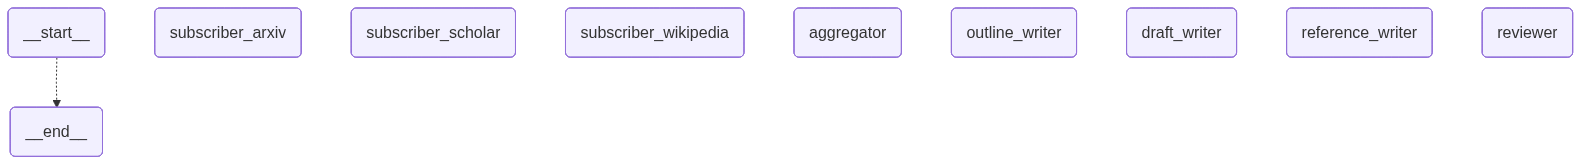

In [12]:
from IPython.display import Image, display, Markdown
print("节点：", list(app.get_graph().nodes))
display(Image(app.get_graph().draw_mermaid_png()))